In [13]:
!pip install scikit-learn
!pip install matplotlib
!pip install seaborn

📂 Step 1: Loading Data from Data.csv...
✅ Loaded: 2200 rows, 13 columns

🔍 Step 2: Initial Inspection...
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   N                    2200 non-null   int64  
 1   P                    2200 non-null   int64  
 2   K                    2200 non-null   int64  
 3   temperature          2200 non-null   float64
 4   humidity             2200 non-null   float64
 5   ph                   2200 non-null   float64
 6   rainfall             2200 non-null   float64
 7   label                2200 non-null   str    
 8   fertilizer           2200 non-null   str    
 9   N_status             2200 non-null   str    
 10  P_status             2200 non-null   str    
 11  K_status             2200 non-null   str    
 12  recommendation_note  2200 non-null   str    
dtypes: float64(4), int64(3), str(6)
memory usage

/tmp/ipykernel_15122/4033957718.py:45: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


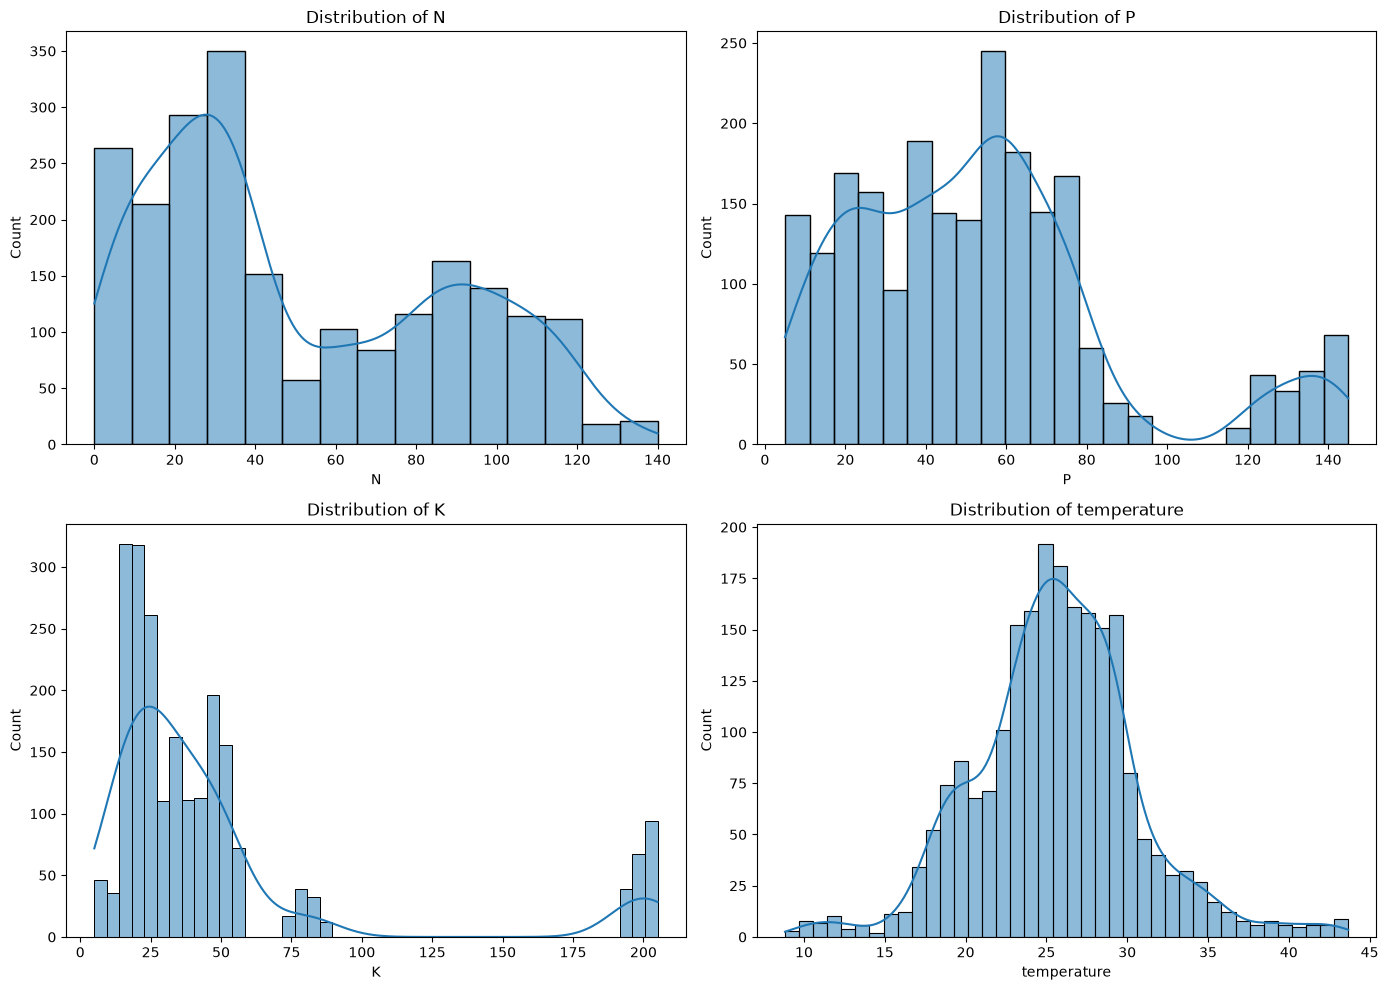


🔗 Step 7: Bivariate Analysis...

📈 Step 8: Correlation Analysis...


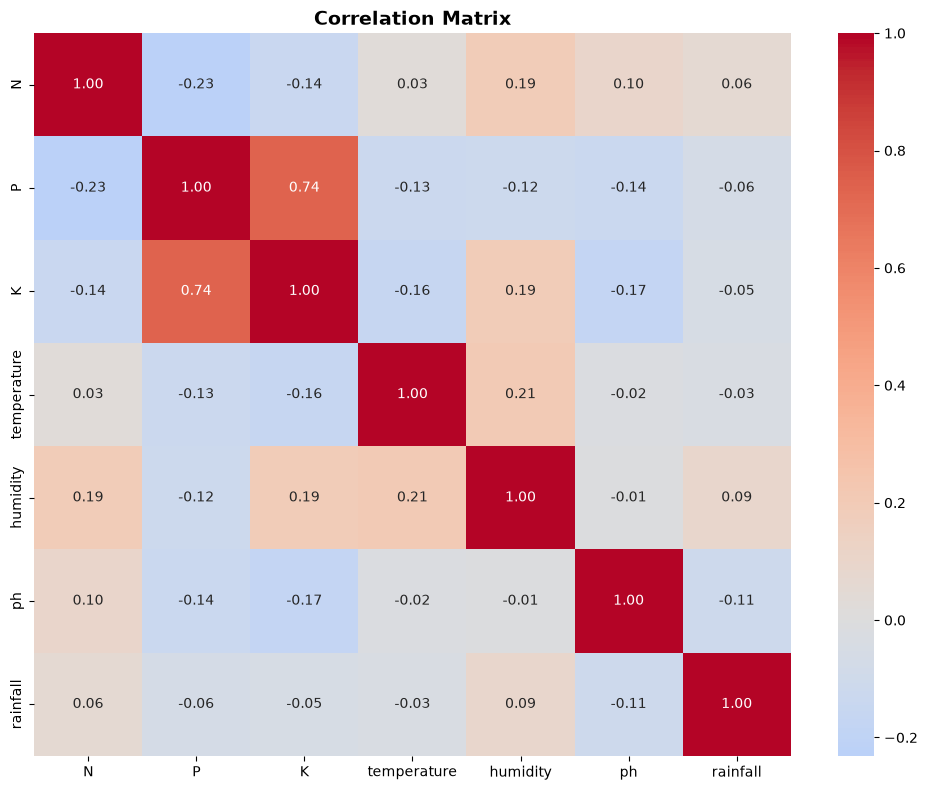


💾 Step 9: Saving Cleaned Data...
✅ EDA Complete! บันทึกไฟล์ 'Data_cleaned_EDA.csv' เรียบร้อย พร้อมนำไปใช้ต่อในขั้นตอน Encoding และ Train Model


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# COMPREHENSIVE EDA WORKFLOW — วิเคราะห์ข้อมูลจาก Data.csv
# ============================================================

# Step 1: Load Data
print("📂 Step 1: Loading Data from Data.csv...")
# โหลดไฟล์ Data.csv จากเครื่อง
df = pd.read_csv('Data.csv')
print(f"✅ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# Step 2: Initial Inspection
print("\n🔍 Step 2: Initial Inspection...")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

# Step 3: Check Missing Values & Duplicates
print("\n⚠️ Step 3: Checking Missing Values & Duplicates...")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_pct.round(2)
})
print(missing_report[missing_report['Missing Count'] > 0])

num_duplicates = df.duplicated().sum()
print(f"\nพบข้อมูลซ้ำซ้อน (Duplicates): {num_duplicates} แถว")

# Step 4: Handle Missing Values & Data Cleaning
print("\n🔧 Step 4: Handling Missing Values & Data Cleaning...")

# 4.1 ลบข้อมูลซ้ำ
if num_duplicates > 0:
    df = df.drop_duplicates()
    print(f"✅ ลบแถวซ้ำออกเรียบร้อยแล้ว คงเหลือ {len(df)} แถว")

# 4.2 จัดการค่าว่างอัตโนมัติตามประเภทข้อมูล
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

# เติมค่าว่างคอลัมน์ตัวเลขด้วย Median
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# เติมค่าว่างคอลัมน์ข้อความด้วย Mode (ค่าพบบ่อยสุด)
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# 4.3 ตัดคอลัมน์ที่มีค่าว่างมากเกินไป (เช่น ข้อมูลหายไปมากกว่า 50%) ออก
thresh = len(df) * 0.5
df = df.dropna(thresh=thresh, axis=1)

print("✅ จัดการค่าว่างและทำความสะอาดข้อมูลเรียบร้อย!")

# Step 5: Feature Engineering
print("\n💡 Step 5: Feature Engineering...")
# ตรวจสอบว่ามีคอลัมน์ครอบครัว (เช่น ใน Titanic) หรือไม่
sibsp_col = next((c for c in ['sibsp', 'SibSp'] if c in df.columns), None)
parch_col = next((c for c in ['parch', 'Parch'] if c in df.columns), None)

if sibsp_col and parch_col:
    df['family_size'] = df[sibsp_col] + df[parch_col] + 1
    df['is_alone'] = (df['family_size'] == 1).astype(int)
    print("✅ สร้างฟีเจอร์ family_size และ is_alone เรียบร้อย!")
else:
    print("ℹ️ ข้ามการสร้างฟีเจอร์เฉพาะ (ไม่พบคอลัมน์ที่เกี่ยวข้อง)")

# Step 6: Univariate Analysis (วิเคราะห์รายคอลัมน์)
print("\n📊 Step 6: Univariate Analysis...")
plot_cols = df.select_dtypes(include=[np.number]).columns[:4]

if len(plot_cols) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(plot_cols):
        sns.histplot(df[col], kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {col}')
        
    plt.tight_layout()
    plt.show()

# Step 7: Bivariate Analysis (วิเคราะห์ความสัมพันธ์ระหว่างคอลัมน์)
print("\n🔗 Step 7: Bivariate Analysis...")
target_col = next((c for c in ['survived', 'Survived', 'target', 'Target'] if c in df.columns), None)

if target_col and len(numeric_cols) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # พล็อตตัวแปรเป้าหมาย
    sns.countplot(x=target_col, data=df, ax=axes[0])
    axes[0].set_title(f'Target Distribution ({target_col})')
    
    # พล็อตความสัมพันธ์กับคอลัมน์ตัวเลขอื่น
    other_col = [c for c in numeric_cols if c != target_col][0]
    sns.boxplot(x=target_col, y=other_col, data=df, ax=axes[1])
    axes[1].set_title(f'{other_col} by {target_col}')
    
    plt.tight_layout()
    plt.show()

# Step 8: Correlation Analysis (เมทริกซ์ความสัมพันธ์)
print("\n📈 Step 8: Correlation Analysis...")
numeric_df = df.select_dtypes(include=[np.number])
if not numeric_df.empty:
    plt.figure(figsize=(10, 8))
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Step 9: Save Cleaned Data
print("\n💾 Step 9: Saving Cleaned Data...")
df.to_csv('Data_cleaned_EDA.csv', index=False)
print("=" * 50)
print("✅ EDA Complete! บันทึกไฟล์ 'Data_cleaned_EDA.csv' เรียบร้อย พร้อมนำไปใช้ต่อในขั้นตอน Encoding และ Train Model")
print("=" * 50)